# Analyse probing results

Loads every `probing/experiment.py` run under `OUTPUTS_ROOTS` (default
`outputs_probing_colon/`, see `configs/probing_colon.yaml`'s `output_dir`) and
plots them, with a tickable list of which model/correction/token
("embeddings") combinations to include.

## Output layout this reads (see `experiment.py`'s `main()` / `run_split_experiment`)

```
{OUTPUTS_ROOT}/{model_name}/{correction_name}/{mapping}/{matching}/{embeddings}/{split_label}/
    split_informations.yaml
    probes_summary.yaml              <- one entry per probe: {skipped, best_lambda,
                                         val_selection_metric, test_selection_metric}
                                         or {skipped: true, reason: ...}
    {probe_name}/
        results_summary.yaml         <- full per-probe detail: task_type, target_columns,
                                         n_train/n_val/n_test, best_val_metrics, best_test_metrics
        lambda_sweep_results.csv
        per_cell_results.csv
```

`embeddings` is the path segment that encodes **which token(s)** a run used
(`data.embeddings_datasets` -- e.g. `cls`, or the sorted-and-joined corner keys,
or `default` if that config list was left empty, meaning "average every
`embeddings_*` key found in the h5 file"). **This is only meaningful if you gave
different runs of the same model/correction a distinct `embeddings_datasets`
config** -- it's recorded per run, so as long as you did that, this notebook's
"tokens" picker is exactly this segment.

`selection_metric` is R² (`r2_mean`) for every probe except `orientation`,
which uses `-mean_angular_error_deg` instead (circular, mod-180 -- see
`probes/cell_level.py::OrientationProbe.eval_metrics`); this notebook plots
orientation's raw degrees separately too, since R²/degrees aren't comparable
on the same axis.

In [32]:
import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(REPO_ROOT))


def _load_dotenv(path: Path) -> None:
    """Minimal `.env` loader (KEY=value per line) -- avoids an extra dependency.
    Mirrors how every other entry point in this repo expects env vars to be set
    (see src/python/code_configs/paths.py)."""
    if not path.exists():
        return
    for line in path.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, _, value = line.partition("=")
        key, value = key.strip(), value.strip()
        if value:
            os.environ.setdefault(key, value)


_load_dotenv(REPO_ROOT / ".env")

In [33]:
import math

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    _HAVE_WIDGETS = True
except ImportError:
    _HAVE_WIDGETS = False
    print("ipywidgets is not installed (`pip install ipywidgets`) -- falling back to the plain "
          "SELECTED_CONDITIONS list in the picker cell below; install it for the tickable checkbox UI.")

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

## Config

Point `OUTPUTS_ROOTS` at one or more roots holding the `{model_name}/...` tree
(a local copy of `outputs_probing_colon/`, or wherever `configs/probing_colon.yaml`'s
`output_dir` was set to). `MAPPING` / `MATCHING` / `CORRECTION_NAME` only need to
be set if a root mixes more than one value of that path segment -- leave `None`
to auto-detect (a warning prints, and nothing gets filtered out, if more than
one value is found). `correction_name` is *not* forced by default the same way
-- it's folded into the tickable "condition" label below alongside model/token,
since (per `probing_colon.yaml`'s own comment) it's a real axis people compare
(e.g. `Base` vs. a batch-correction method), not just a fixed experiment-design
choice.

In [34]:
OUTPUTS_ROOTS = [Path("../outputs_probing_colon")]

MAPPING = None    # e.g. "simplified_broad" -- force one value if a root mixes several
MATCHING = None   # e.g. "matching" or "all_cells"

## Loading

Two passes, mirroring the two YAML files `experiment.py` writes:

1. `load_probe_summaries` walks every `probes_summary.yaml` (one per split --
   cheap, and the only place a *skipped* probe is recorded at all, with its
   skip reason).
2. `load_probe_details` enriches each non-skipped row with its probe's own
   `results_summary.yaml` (`n_train`/`n_val`/`n_test` and the full
   `best_val_metrics`/`best_test_metrics` dict, flattened with a `val_`/`test_`
   prefix -- `r2_<col>`, `r2_mean`, and, for `orientation` only,
   `r2_orientation_cos2`/`r2_orientation_sin2`/`mean_angular_error_deg`).

In [35]:
SCHEMA = ("model_name", "correction_name", "mapping", "matching", "embeddings")


def _flatten(prefix: str, d: dict) -> dict:
    return {f"{prefix}_{k}": v for k, v in d.items()}


def _split_idx(split_label: str) -> int | None:
    return None if split_label == "same_wsi_split" else int(split_label.removeprefix("split_"))


def load_probe_summaries(root: Path) -> pd.DataFrame:
    """One row per (run, probe) from every probes_summary.yaml under root --
    includes skipped probes (skipped=True, reason=..., no metrics)."""
    rows: list[dict] = []
    for summary_path in sorted(root.rglob("probes_summary.yaml")):
        parts = summary_path.relative_to(root).parts[:-1]  # drop the filename itself
        if len(parts) != len(SCHEMA) + 1:  # + split_label
            print(f"[skip] unexpected path depth ({len(parts)} != {len(SCHEMA) + 1}): {summary_path}")
            continue
        meta = dict(zip(SCHEMA, parts[:-1]))
        split_label = parts[-1]

        with open(summary_path) as f:
            probes = yaml.safe_load(f) or {}

        for probe_name, entry in probes.items():
            rows.append({
                **meta, "split_label": split_label, "split_idx": _split_idx(split_label),
                "is_same_wsi": split_label == "same_wsi_split",
                "probe_dir": summary_path.parent / probe_name.replace("@", "_"),
                "probe": probe_name, **(entry or {}),
            })
    return pd.DataFrame(rows)


def load_probe_details(df: pd.DataFrame) -> pd.DataFrame:
    """Enrich non-skipped rows with their probe's own results_summary.yaml.

    best_val_metrics/best_test_metrics each already contain a "selection_metric"
    key (it's literally where probes_summary.yaml's val_/test_selection_metric
    came from, see experiment.py) -- dropped here before flattening so it isn't
    duplicated against the val_selection_metric/test_selection_metric columns
    load_probe_summaries already added (pd.concat'ing two frames that both have
    a same-named column produces a *duplicate* column, not an overwrite, which
    silently turns every single-column selection downstream into a 2-column one)."""
    extra_rows = []
    for _, row in df.iterrows():
        extra: dict = {}
        if not row.get("skipped", True):
            path = Path(row["probe_dir"]) / "results_summary.yaml"
            if path.exists():
                with open(path) as f:
                    summary = yaml.safe_load(f)
                val_metrics = dict(summary.get("best_val_metrics") or {})
                test_metrics = dict(summary.get("best_test_metrics") or {})
                val_metrics.pop("selection_metric", None)
                test_metrics.pop("selection_metric", None)
                extra = {
                    "task_type": summary.get("task_type"), "target_columns": summary.get("target_columns"),
                    "n_train": summary.get("n_train"), "n_val": summary.get("n_val"), "n_test": summary.get("n_test"),
                    **_flatten("val", val_metrics),
                    **_flatten("test", test_metrics),
                }
        extra_rows.append(extra)
    extra_df = pd.DataFrame(extra_rows, index=df.index)
    return pd.concat([df, extra_df], axis=1)


def _pick(df: pd.DataFrame, col: str, forced):
    values = df[col].unique().tolist()
    if forced is not None:
        return forced
    if len(values) > 1:
        print(f"[warning] multiple {col!r} values found {values} -- "
              f"set {col.upper()} above to filter to one; keeping all of them for now")
        return None
    return values[0]


results_df = pd.concat([load_probe_summaries(root) for root in OUTPUTS_ROOTS], ignore_index=True)
assert not results_df.empty, f"no probes_summary.yaml found under {[str(r.resolve()) for r in OUTPUTS_ROOTS]}"
results_df = load_probe_details(results_df)

for col, forced in (("mapping", MAPPING), ("matching", MATCHING)):
    picked = _pick(results_df, col, forced)
    if picked is not None:
        results_df = results_df[results_df[col] == picked]

results_df["condition"] = (
    results_df["model_name"] + " | " + results_df["correction_name"] + " | " + results_df["embeddings"]
)

print(f"Loaded {len(results_df)} (run x probe) rows -- "
      f"{results_df['condition'].nunique()} condition(s): {sorted(results_df['condition'].unique())}; "
      f"probes: {sorted(results_df['probe'].unique())}")
results_df.head()

Loaded 1635 (run x probe) rows -- 18 condition(s): ['HOptimus1 | raw | bottom_left_bottom_right_top_left_top_right', 'HOptimus1_100_resized | raw | bottom_left_bottom_right_top_left_top_right', 'PhikonV2_100_resized | raw | bottom_left_bottom_right_top_left_top_right', 'PhikonV2_448 | raw | bottom_left_bottom_right_top_left_top_right', 'PhikonV2_448 | raw | cls', 'PhikonV2_448 | raw | default', 'PhikonV2_448_masked | raw | bottom_left_bottom_right_top_left_top_right', 'PhikonV2_448_masked | raw | cls', 'PhikonV2_448_masked | raw | default', 'UNI2_100_resized | raw | bottom_left_bottom_right_top_left_top_right', 'UNI2_100_resized | raw | cls', 'UNI2_448_resized | raw | cls', 'UNI2_specific_tokens_folder | raw | bottom_left_bottom_right_top_left_top_right', 'UNI2_specific_tokens_folder | raw | cls', 'UNI2_specific_tokens_folder | raw | default', 'UNI2_specific_tokens_folder | raw | nucleus', 'virchow_v2 | raw | bottom_left_bottom_right_top_left_top_right', 'virchow_v2_100_resized | raw |

,model_name,correction_name,mapping,matching,embeddings,split_label,split_idx,is_same_wsi,probe_dir,probe,best_lambda,skipped,test_selection_metric,val_selection_metric,reason,task_type,target_columns,n_train,n_val,n_test,...,test_r2_frac_Myeloid,test_r2_frac_Stromal,test_r2_frac_Unknown,val_r2_eccentricity,test_r2_eccentricity,val_mean_angular_error_deg,val_r2_orientation_cos2,val_r2_orientation_sin2,test_mean_angular_error_deg,test_r2_orientation_cos2,test_r2_orientation_sin2,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,condition
0,HOptimus1,raw,simplified_broad,all_cells,bottom_left_bottom_right_top_left_top_right,split_0,0,False,../outputs_probing_colon/HOptimus1/raw/simplif...,area,1000.0,False,0.540005,0.473784,NaN,regression,[log1p_area],813153.0,263823.0,209567.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HOptimus1 | raw | bottom_left_bottom_right_top...
1,HOptimus1,raw,simplified_broad,all_cells,bottom_left_bottom_right_top_left_top_right,split_0,0,False,../outputs_probing_colon/HOptimus1/raw/simplif...,cell_count@1344px,1000.0,False,0.425902,-0.282275,NaN,regression,[log1p_cell_count],813153.0,263823.0,209567.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HOptimus1 | raw | bottom_left_bottom_right_top...
2,HOptimus1,raw,simplified_broad,all_cells,bottom_left_bottom_right_top_left_top_right,split_0,0,False,../outputs_probing_colon/HOptimus1/raw/simplif...,cell_count@224px,1000.0,False,0.695877,0.229010,NaN,regression,[log1p_cell_count],813153.0,263823.0,209567.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HOptimus1 | raw | bottom_left_bottom_right_top...
3,HOptimus1,raw,simplified_broad,all_cells,bottom_left_bottom_right_top_left_top_right,split_0,0,False,../outputs_probing_colon/HOptimus1/raw/simplif...,cell_count@448px,1000.0,False,0.638218,-0.032640,NaN,regression,[log1p_cell_count],813153.0,263823.0,209567.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HOptimus1 | raw | bottom_left_bottom_right_top...
4,HOptimus1,raw,simplified_broad,all_cells,bottom_left_bottom_right_top_left_top_right,split_0,0,False,../outputs_probing_colon/HOptimus1/raw/simplif...,cell_density@1344px,1000.0,False,0.455490,-0.138532,NaN,regression,[log1p_cell_density_per_100px2],813153.0,263823.0,209567.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HOptimus1 | raw | bottom_left_bottom_right_top...


## Plotting helpers

`render(selected_conditions)` redraws everything below from `results_df`
filtered to `selected_conditions` -- the picker cell further down just calls
this on every tick. Faceted per probe throughout, since `selection_metric`'s
scale/sign differs by probe type (R² vs. `-mean_angular_error_deg`) -- each
probe gets its own subplot with its own y-axis.

In [36]:
def _metric_grid(n: int, figsize_per=(5.5, 4)):
    ncols = 2 if n > 1 else 1
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per[0] * ncols, figsize_per[1] * nrows), squeeze=False)
    axes = axes.flatten()
    for ax in axes[n:]:
        ax.axis("off")
    return fig, axes


def _grouped_bar(ax, pivot_mean: pd.DataFrame, pivot_std: pd.DataFrame, ylabel: str):
    """pivot_*: index=condition, columns=hue (e.g. ['val', 'test'] or ['LWO mean', 'same_wsi_split'])."""
    conditions = pivot_mean.index.tolist()
    hues = pivot_mean.columns.tolist()
    x = np.arange(len(conditions))
    width = 0.8 / max(len(hues), 1)
    for i, hue in enumerate(hues):
        means = pivot_mean[hue].values
        stds = pivot_std[hue].values if pivot_std is not None and hue in pivot_std else np.zeros_like(means)
        ax.bar(x + i * width - 0.4 + width / 2, means, width=width, yerr=stds, capsize=3, label=str(hue))
    ax.set_xticks(x)
    ax.set_xticklabels(conditions, rotation=25, ha="right", fontsize=7)
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7)
    ax.grid(axis="y", alpha=0.3)
    ax.axhline(0, color="black", linewidth=0.6)


def plot_val_vs_test_by_probe(df: pd.DataFrame) -> None:
    """LWO-only: mean +/- std selection_metric across splits, val vs test, one subplot per probe."""
    loso = df[~df["is_same_wsi"]]
    probes = sorted(loso["probe"].unique())
    cols = ["val_selection_metric", "test_selection_metric"]
    rename = {"val_selection_metric": "val", "test_selection_metric": "test"}
    fig, axes = _metric_grid(len(probes))
    for ax, probe in zip(axes, probes):
        grouped = loso[loso["probe"] == probe].groupby("condition")[cols]
        mean_pivot = grouped.mean().rename(columns=rename)
        std_pivot = grouped.std().rename(columns=rename)
        _grouped_bar(ax, mean_pivot, std_pivot, "selection_metric")
        ax.set_title(probe, fontsize=9)
    fig.suptitle("selection_metric: mean +/- std across LWO splits (val vs. test)")
    fig.tight_layout()
    plt.show()


def plot_per_split_lines(df: pd.DataFrame, value_col: str = "test_selection_metric") -> None:
    """LWO-only: value_col per split_idx, one line per condition, one subplot per probe --
    the fold-to-fold stability check (is a probe's result consistent across held-out WSIs,
    or is one fold an outlier?)."""
    loso = df[~df["is_same_wsi"]]
    probes = sorted(loso["probe"].unique())
    fig, axes = _metric_grid(len(probes))
    for ax, probe in zip(axes, probes):
        sub = loso[loso["probe"] == probe]
        pivot = sub.pivot_table(index="split_idx", columns="condition", values=value_col)
        for condition in pivot.columns:
            ax.plot(pivot.index, pivot[condition], marker="o", label=condition, markersize=4)
        ax.set_title(probe, fontsize=9)
        ax.set_xlabel("split_idx")
        ax.grid(alpha=0.3)
    axes[0].legend(fontsize=6, loc="best")
    fig.suptitle(f"{value_col} per LWO split")
    fig.tight_layout()
    plt.show()


def plot_lwo_vs_same_wsi(df: pd.DataFrame, value_col: str = "test_selection_metric") -> None:
    """LWO mean vs. same_wsi_split (pooled 70/15/15 across all WSIs) for value_col,
    one subplot per probe -- the WSI-transfer check: a big gap here means the target
    only "works" when train/test share a slide (see geometry.py's orientation_deg,
    defined in each WSI's own absolute pixel frame)."""
    loso = df[~df["is_same_wsi"]]
    same_wsi = df[df["is_same_wsi"]]
    probes = sorted(df["probe"].unique())
    fig, axes = _metric_grid(len(probes))
    for ax, probe in zip(axes, probes):
        lwo_mean = loso[loso["probe"] == probe].groupby("condition")[value_col].mean().rename("LWO mean")
        sw = same_wsi[same_wsi["probe"] == probe].groupby("condition")[value_col].mean().rename("same_wsi_split")
        pivot_mean = pd.concat([lwo_mean, sw.reindex(lwo_mean.index)], axis=1)
        _grouped_bar(ax, pivot_mean, None, value_col)
        ax.set_title(probe, fontsize=9)
    fig.suptitle(f"{value_col}: Leave-WSI-Out mean vs. same-WSI upper bound")
    fig.tight_layout()
    plt.show()


def plot_orientation_degrees(df: pd.DataFrame) -> None:
    """Orientation's own selection_metric is -mean_angular_error_deg -- not comparable
    to other probes' R^2 on the same axis, so it gets its own degrees-native view, with
    the two reference lines that make the number interpretable: 45 deg = chance (two
    independent mod-180 angles), 90 deg = worst case (systematically perpendicular)."""
    orient = df[df["probe"] == "orientation"]
    if orient.empty:
        return

    loso = orient[~orient["is_same_wsi"]]
    same_wsi = orient[orient["is_same_wsi"]]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    pivot = loso.pivot_table(index="split_idx", columns="condition", values="test_mean_angular_error_deg")
    for condition in pivot.columns:
        axes[0].plot(pivot.index, pivot[condition], marker="o", label=condition, markersize=4)
    axes[0].axhline(45, color="gray", linestyle="--", linewidth=1, label="45 deg = chance")
    axes[0].axhline(90, color="red", linestyle=":", linewidth=1, label="90 deg = worst case")
    axes[0].set_xlabel("split_idx")
    axes[0].set_ylabel("test mean angular error (deg)")
    axes[0].set_title("orientation: per-split test error")
    axes[0].legend(fontsize=6)
    axes[0].grid(alpha=0.3)

    lwo_mean = loso.groupby("condition")["test_mean_angular_error_deg"].mean().rename("LWO mean")
    sw = same_wsi.groupby("condition")["test_mean_angular_error_deg"].mean().rename("same_wsi_split")
    pivot_mean = pd.concat([lwo_mean, sw.reindex(lwo_mean.index)], axis=1)
    _grouped_bar(axes[1], pivot_mean, None, "test mean angular error (deg)")
    axes[1].axhline(45, color="gray", linestyle="--", linewidth=1)
    axes[1].axhline(90, color="red", linestyle=":", linewidth=1)
    axes[1].set_title("orientation: LWO mean vs. same-WSI")

    fig.suptitle("orientation probe, in its native units (deg) -- not comparable to other probes' R^2")
    fig.tight_layout()
    plt.show()


def render(selected_conditions: list[str]) -> None:
    df = results_df[results_df["condition"].isin(selected_conditions)]
    if df.empty:
        print("No rows match the current selection.")
        return

    skipped = df[df["skipped"] == True]  # noqa: E712 -- explicit bool compare reads clearer here
    if not skipped.empty:
        print(f"{len(skipped)} skipped (probe, run) row(s) in this selection:")
        print(skipped[["condition", "split_label", "probe", "reason"]].to_string(index=False))

    fit = df[df["skipped"] == False]  # noqa: E712
    if fit.empty:
        print("Every selected row was skipped -- nothing to plot.")
        return

    plot_val_vs_test_by_probe(fit)
    plot_per_split_lines(fit, "test_selection_metric")
    plot_lwo_vs_same_wsi(fit, "test_selection_metric")
    plot_orientation_degrees(fit)

    print(f"\n{len(fit)} fitted (run x probe) rows for the current selection:")
    display_cols = ["condition", "split_label", "probe", "best_lambda", "n_train", "n_val", "n_test",
                     "val_selection_metric", "test_selection_metric"]
    print(fit[display_cols].sort_values(["condition", "probe", "split_label"]).to_string(index=False))

In [37]:
results_df

,model_name,correction_name,mapping,matching,embeddings,split_label,split_idx,is_same_wsi,probe_dir,probe,best_lambda,skipped,test_selection_metric,val_selection_metric,reason,task_type,target_columns,n_train,n_val,n_test,...,test_r2_frac_Myeloid,test_r2_frac_Stromal,test_r2_frac_Unknown,val_r2_eccentricity,test_r2_eccentricity,val_mean_angular_error_deg,val_r2_orientation_cos2,val_r2_orientation_sin2,test_mean_angular_error_deg,test_r2_orientation_cos2,test_r2_orientation_sin2,val_accuracy,val_balanced_accuracy,val_macro_f1,val_weighted_f1,test_accuracy,test_balanced_accuracy,test_macro_f1,test_weighted_f1,condition
0,HOptimus1,raw,simplified_broad,all_cells,bottom_left_bottom_right_top_left_top_right,split_0,0,False,../outputs_probing_colon/HOptimus1/raw/simplif...,area,1000.000,False,0.540005,0.473784,NaN,regression,[log1p_area],813153.0,263823.0,209567.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HOptimus1 | raw | bottom_left_bottom_right_top...
1,HOptimus1,raw,simplified_broad,all_cells,bottom_left_bottom_right_top_left_top_right,split_0,0,False,../outputs_probing_colon/HOptimus1/raw/simplif...,cell_count@1344px,1000.000,False,0.425902,-0.282275,NaN,regression,[log1p_cell_count],813153.0,263823.0,209567.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HOptimus1 | raw | bottom_left_bottom_right_top...
2,HOptimus1,raw,simplified_broad,all_cells,bottom_left_bottom_right_top_left_top_right,split_0,0,False,../outputs_probing_colon/HOptimus1/raw/simplif...,cell_count@224px,1000.000,False,0.695877,0.229010,NaN,regression,[log1p_cell_count],813153.0,263823.0,209567.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HOptimus1 | raw | bottom_left_bottom_right_top...
3,HOptimus1,raw,simplified_broad,all_cells,bottom_left_bottom_right_top_left_top_right,split_0,0,False,../outputs_probing_colon/HOptimus1/raw/simplif...,cell_count@448px,1000.000,False,0.638218,-0.032640,NaN,regression,[log1p_cell_count],813153.0,263823.0,209567.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HOptimus1 | raw | bottom_left_bottom_right_top...
4,HOptimus1,raw,simplified_broad,all_cells,bottom_left_bottom_right_top_left_top_right,split_0,0,False,../outputs_probing_colon/HOptimus1/raw/simplif...,cell_density@1344px,1000.000,False,0.455490,-0.138532,NaN,regression,[log1p_cell_density_per_100px2],813153.0,263823.0,209567.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HOptimus1 | raw | bottom_left_bottom_right_top...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1630,virchow_v2_100_resized,raw,simplified_broad,all_cells,bottom_left_bottom_right_top_left_top_right,split_7,7,False,../outputs_probing_colon/virchow_v2_100_resize...,cell_type_composition@1344px,1000.000,False,-1.221485,-0.261095,NaN,regression,"[frac_Epithelial, frac_Lymphoid, frac_Malignan...",570779.0,263823.0,451941.0,...,-1.114210,0.161317,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,virchow_v2_100_resized | raw | bottom_left_bot...
1631,virchow_v2_100_resized,raw,simplified_broad,all_cells,bottom_left_bottom_right_top_left_top_right,split_7,7,False,../outputs_probing_colon/virchow_v2_100_resize...,cell_type_composition@224px,1000.000,False,-0.872474,0.074380,NaN,regression,"[frac_Epithelial, frac_Lymphoid, frac_Malignan...",570779.0,263823.0,451941.0,...,-0.239244,0.267248,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,virchow_v2_100_resized | raw | bottom_left_bot...
1632,virchow_v2_100_resized,raw,simplified_broad,all_cells,bottom_left_bottom_right_top_left_top_right,split_7,7,False,../outputs_probing_colon/virchow_v2_100_resize...,cell_type_composition@448px,1000.000,False,-0.921176,-0.020554,NaN,regression,"[frac_Epithelial, frac_Lymphoid, frac_Malignan...",57

## Pick which models / corrections / tokens to plot

One checkbox per `condition` (`model_name | correction_name | embeddings`) --
tick/untick and the plots above redraw automatically. Falls back to a plain
`SELECTED_CONDITIONS` list (edit it directly, then re-run this cell) if
`ipywidgets` isn't installed.

In [38]:
ALL_CONDITIONS = sorted(results_df["condition"].unique())

if _HAVE_WIDGETS:
    _checkboxes = [widgets.Checkbox(value=True, description=c, indent=False,
                                     layout=widgets.Layout(width="max-content"))
                   for c in ALL_CONDITIONS]
    _output_area = widgets.Output()

    def _on_change(_change):
        selected = [cb.description for cb in _checkboxes if cb.value]
        with _output_area:
            clear_output(wait=True)
            render(selected)

    for _cb in _checkboxes:
        _cb.observe(_on_change, names="value")

    _select_all = widgets.Button(description="Select all", layout=widgets.Layout(width="100px"))
    _select_none = widgets.Button(description="Select none", layout=widgets.Layout(width="100px"))

    def _set_all(_btn, value: bool):
        for cb in _checkboxes:
            cb.unobserve(_on_change, names="value")
        for cb in _checkboxes:
            cb.value = value
        for cb in _checkboxes:
            cb.observe(_on_change, names="value")
        _on_change(None)

    _select_all.on_click(lambda _btn: _set_all(_btn, True))
    _select_none.on_click(lambda _btn: _set_all(_btn, False))

    picker = widgets.VBox([
        widgets.HBox([widgets.HTML("<b>Models / corrections / tokens to plot:</b>"), _select_all, _select_none]),
        widgets.VBox(_checkboxes, layout=widgets.Layout(max_height="240px", overflow="auto", border="1px solid #ccc")),
    ])
    display(picker, _output_area)
    _on_change(None)
else:
    SELECTED_CONDITIONS = list(ALL_CONDITIONS)  # edit this list, then re-run this cell
    render(SELECTED_CONDITIONS)

Output()

## Masking drift vs. biological difference from surroundings

Tests whether **drift** -- cosine distance between a cell's CLS embedding from an
*unmasked* run and its CLS embedding from the matching run where only that cell's
own central `mask_grid_size x mask_grid_size` tokens were masked (see
`extract_embeddings/data/central_mask.py`, `extract_embeddings.py`'s
`masked_448_configs` / `phikon_v2_masked_configs`) -- is higher for cells that are
biologically distinct from their surroundings, using real Xenium ground truth (not
image features) to define "biologically distinct":

1. **Categorical**: `heterotypic_frac` -- fraction of spatially nearby cells (within
   `CONTEXT_PX`, from `patch_coordinates.h5`'s full detected-cell population) whose
   mapped `cell_type` differs from this cell's own. `isolated` -- no other detected
   cell nearby at all.
2. **Continuous / expression**: correlate (Pearson, and 1 - cosine similarity) each
   cell's own log-normalized Xenium transcript profile (`adata.h5ad`) against the
   mean profile of its spatial neighbours -- low correlation / high distance means
   this cell doesn't transcriptionally resemble its neighbourhood.

Unlike the rest of this notebook (which only reads the lightweight
`outputs_probing_colon/` summaries), this section re-reads the raw per-cell
`embeddings_dataset.h5` / `patch_coordinates.h5` / `adata.h5ad` files directly, so it
needs `DATASETS_ROOT` and `XENIUM_PROCESSED_OUTPUT_ROOT` set (see `.env`) and a
masked/unmasked model pair actually extracted (an `X` and `X_masked` `model_name`
under the same `correction_name`).

**Statistical test**: cells from the same WSI aren't independent (shared tissue
architecture, staining, spatially autocorrelated neighbourhoods), so a plain pooled
Spearman p-value would be anti-conservative. We test the pooled Spearman correlation
between drift and each biological-difference score with a **within-WSI
block-permutation** null (shuffles preserve each WSI's own marginal and all
between-WSI structure), cross-check it against **per-WSI correlations** combined via
**Stouffer's method** (does every WSI agree on direction?), and test the
isolated-vs-surrounded contrast with a **WSI-cluster bootstrap** CI on top of the
(anti-conservative, reported for reference only) Mann-Whitney p-value.

In [39]:
# ── Config ────────────────────────────────────────────────────────────────
import h5py
from scipy import stats
from scipy.stats import rankdata
from scipy.spatial import cKDTree
import anndata as ad

from src.python.code_configs import paths
from src.python.code_configs.mappings import mapping_factory
from src.python.probing.data.cell_population import PopulationCache
from src.python.probing.probes.base import group_ranges

# Auto-detect every (unmasked_model_name, masked_model_name, correction_name) triple
# present in results_df -- a "masked" run is any model_name ending in "_masked" whose
# non-"_masked" counterpart was also probed under the same correction_name.
_known_runs = set(zip(results_df["model_name"], results_df["correction_name"]))
MASKED_UNMASKED_PAIRS = sorted(
    (masked[: -len("_masked")], masked, correction)
    for masked, correction in _known_runs
    if masked.endswith("_masked") and (masked[: -len("_masked")], correction) in _known_runs
)
assert MASKED_UNMASKED_PAIRS, (
    "No masked/unmasked model_name pair found in results_df -- this analysis needs both an "
    "'X' and an 'X_masked' run under the same correction_name (see extract_embeddings.py's "
    "masked_448_configs / phikon_v2_masked_configs)."
)
print("Detected masked/unmasked pairs:", MASKED_UNMASKED_PAIRS)

DRIFT_PAIR = MASKED_UNMASKED_PAIRS[0]                 # (unmasked_model, masked_model, correction_name)
DRIFT_EMBEDDINGS_DATASET = ['bottom_left', 'bottom_right', 'top_left', 'top_right']                   # global patch summary -- see markdown above
CONTEXT_PX = 448                                       # matches these runs' size_side=448 field of view
MIN_NEIGHBORS = 3                                      # below this, heterotypic_frac / expr correlation -> NaN
print(f"Analysing pair: {DRIFT_PAIR}, embeddings={DRIFT_EMBEDDINGS_DATASET}, context_px={CONTEXT_PX}")

Detected masked/unmasked pairs: [('PhikonV2_448', 'PhikonV2_448_masked', 'raw')]
Analysing pair: ('PhikonV2_448', 'PhikonV2_448_masked', 'raw'), embeddings=['bottom_left', 'bottom_right', 'top_left', 'top_right'], context_px=448


### Load raw per-cell embeddings and compute drift

Re-reads each run's own `embeddings_dataset.h5` files directly (bypassing the
probing pipeline's WSI/cell-type subsampling in `load_probe_population` -- drift is
a property of the two runs themselves, so we want every cell both share, not a
probing-training subsample), matches cells by `cell_id` per WSI, and takes the
cosine distance between the two CLS embeddings.

In [40]:
def _decode_str_array(arr: np.ndarray) -> np.ndarray:
    """h5py reads HDF5 string datasets back as bytes by default -- decode once so
    cell_ids line up with patch_coordinates.h5 / adata.h5ad's plain-str convention
    (mirrors data/cell_population.py's private `_decode`)."""
    if len(arr) and isinstance(arr[0], (bytes, bytearray)):
        return np.array([x.decode("utf-8") for x in arr])
    return arr


def _load_raw_cell_embeddings(base_path: str, wsi_name: str, embeddings_datasets: list[str]):
    """cell_id (decoded str) + embedding for every cell physically present in one
    WSI's embeddings_dataset.h5 -- no WSI/cell-type subsampling or 'matching' filter
    (see module docstring)."""
    with h5py.File(os.path.join(base_path, wsi_name, "embeddings_dataset.h5"), "r") as f:
        datasets = embeddings_datasets or [k.split("embeddings_")[1] for k in f.keys() if k.startswith("embeddings_")]
        embeddings = np.mean([f[f"embeddings_{k}"][()] for k in datasets], axis=0).astype(np.float64)
        cell_ids = _decode_str_array(f["cell_ids"][()])
    return cell_ids, embeddings


def _cosine_distance(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    a_n = a / np.clip(np.linalg.norm(a, axis=1, keepdims=True), 1e-12, None)
    b_n = b / np.clip(np.linalg.norm(b, axis=1, keepdims=True), 1e-12, None)
    return 1.0 - np.sum(a_n * b_n, axis=1)


def compute_drift(unmasked_model: str, masked_model: str, correction_name: str,
                   embeddings_datasets: list[str]) -> pd.DataFrame:
    """Cosine distance between a cell's CLS embedding with vs. without its own
    central tokens masked -- "how much does the model's whole-patch summary change
    when this cell's own appearance is replaced by the generic mask token". Matched
    by cell_id per WSI (inner join)."""
    unmasked_base = os.path.join(paths.DATASETS_ROOT, f"{unmasked_model}_h5", correction_name)
    masked_base = os.path.join(paths.DATASETS_ROOT, f"{masked_model}_h5", correction_name)
    wsi_names = sorted(set(os.listdir(unmasked_base)) & set(os.listdir(masked_base)))
    if not wsi_names:
        raise ValueError(f"No shared WSI directories between {unmasked_base!r} and {masked_base!r}")

    rows = []
    for wsi_name in wsi_names:
        ids_u, emb_u = _load_raw_cell_embeddings(unmasked_base, wsi_name, embeddings_datasets)
        ids_m, emb_m = _load_raw_cell_embeddings(masked_base, wsi_name, embeddings_datasets)
        common, iu, im = np.intersect1d(ids_u, ids_m, return_indices=True)
        if len(common) == 0:
            print(f"[warning] {wsi_name}: no cell_ids shared between {unmasked_model} and {masked_model}")
            continue
        drift = _cosine_distance(emb_u[iu], emb_m[im])
        rows.append(pd.DataFrame({"wsi_name": wsi_name, "cell_id": common, "drift": drift}))
    return pd.concat(rows, ignore_index=True)


drift_df = compute_drift(*DRIFT_PAIR, DRIFT_EMBEDDINGS_DATASET)
print(f"{len(drift_df)} matched cells across {drift_df['wsi_name'].nunique()} WSIs")
drift_df.groupby("wsi_name")["drift"].describe()

2129433 matched cells across 11 WSIs


,count,mean,std,min,25%,50%,75%,max
wsi_name,,,,,,,,
Xenium_Prime_Human_Skin_FFPE,76779.0,0.200248,0.041748,0.075115,0.171380,0.194931,0.223247,0.575652
Xenium_V1_Human_Colon_Cancer_P1_CRC_Add_on_FFPE,209567.0,0.149931,0.049307,0.053689,0.114493,0.141123,0.176023,0.624561
Xenium_V1_Human_Colon_Cancer_P2_CRC_Add_on_FFPE,263823.0,0.122979,0.042947,0.044842,0.091595,0.113938,0.144936,0.549411
Xenium_V1_Human_Colon_Cancer_P5_CRC_Add_on_FFPE,191588.0,0.149692,0.049662,0.050306,0.113687,0.141324,0.176571,0.614282
Xenium_V1_Human_Colorectal_Cancer_Addon_FFPE,311698.0,0.114368,0.040772,0.042973,0.084481,0.103395,0.134639,0.489704
Xenium_V1_Human_Lung_Cancer_Addon_FFPE,107510.0,0.199974,0.045328,0.078592,0.169015,0.193905,0.223839,0.636814
Xenium_V1_Human_Ovarian_Cancer_Addon_FFPE,145133.0,0.189483,0.040085,0.074715,0.161736,0.184426,0.211129,0.580272
Xenium_V1_hColon_Cancer_Add_on_FFPE,451941.0,0.166900,0.040516,0.063082,0.138669,0.161144,0.188411,0.670077
Xenium_V1_hColon_Non_diseased_Base_FFPE,169624.0,0.135241,0.038984,0.054106,0.107934,0.128014,0.154106,0.529494


### Xenium ground truth: biological difference / isolation from surroundings

Two independent, ground-truth-only scores per cell (no image features involved):

- `heterotypic_frac` / `isolated` from `patch_coordinates.h5`'s cell typing (same
  `mapping`/window convention as the `cell_type_composition`/`cell_count` probes above).
- `expr_corr_to_neighbors` / `expr_cosine_dist_to_neighbors` from `adata.h5ad`'s raw
  transcript counts -- the direct "correlation" version of the same question.

Both use every detected cell in the WSI as a potential neighbour, not just cells that
happen to carry an embedding.

In [41]:
def compute_neighbor_type_stats(df: pd.DataFrame, mapping_name: str, context_px: float) -> pd.DataFrame:
    """Xenium ground-truth neighbourhood composition around every (wsi_name, cell_id)
    in df, within a context_px x context_px window centred on the cell (self excluded).
    heterotypic_frac is NaN, and isolated is False, where position_found is False
    (cell_id not present in patch_coordinates.h5 -- can't tell isolated from unresolved)."""
    mapping = mapping_factory(mapping_name)
    pop_cache = PopulationCache(paths.XENIUM_PROCESSED_OUTPUT_ROOT, mapping)
    half = context_px / 2.0
    n = len(df)

    self_type = np.full(n, "", dtype=object)
    position_found = np.zeros(n, dtype=bool)
    n_neighbors = np.zeros(n, dtype=np.int64)
    heterotypic_frac = np.full(n, np.nan)

    wsi_names = df["wsi_name"].to_numpy()
    cell_ids = df["cell_id"].to_numpy()
    order = np.argsort(wsi_names, kind="stable")
    sorted_wsi = wsi_names[order]
    for start, end in group_ranges(sorted_wsi):
        wsi_name = sorted_wsi[start]
        pop = pop_cache.get(wsi_name)
        local_idx = order[start:end]
        rows = np.array([pop.id_to_row.get(cid, -1) for cid in cell_ids[local_idx]])
        valid = rows >= 0
        if not valid.any():
            continue
        v_idx, v_rows = local_idx[valid], rows[valid]
        position_found[v_idx] = True
        self_type[v_idx] = np.array(pop.class_names)[pop.class_idx[v_rows]]
        neighbor_lists = pop.query_windows(pop.x[v_rows], pop.y[v_rows], half)
        for li, row, neighbors in zip(v_idx.tolist(), v_rows.tolist(), neighbor_lists):
            neighbors = np.asarray(neighbors, dtype=np.int64)
            neighbors = neighbors[neighbors != row]
            n_neighbors[li] = len(neighbors)
            if len(neighbors) > 0:
                same = np.count_nonzero(pop.class_idx[neighbors] == pop.class_idx[row])
                heterotypic_frac[li] = 1.0 - same / len(neighbors)

    out = df.copy()
    out["self_cell_type"] = self_type
    out["position_found"] = position_found
    out["n_type_neighbors"] = n_neighbors
    out["heterotypic_frac"] = heterotypic_frac
    out["isolated"] = position_found & (n_neighbors == 0)
    return out


def _pearson_corr(a: np.ndarray, b: np.ndarray) -> float:
    a, b = a - a.mean(), b - b.mean()
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denom) if denom > 0 else np.nan


def _cosine_dist_vec(a: np.ndarray, b: np.ndarray) -> float:
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    return float(1.0 - np.dot(a, b) / denom) if denom > 0 else np.nan


def _load_adata_population(wsi_name: str, target_sum: float = 100.0) -> dict:
    """Per-WSI Xenium expression profile for every detected cell: library-size-
    normalized (to target_sum, small because Xenium panels are only a few hundred
    curated genes -- the scRNA-seq-typical 10000 would blow log1p's useful range)
    then log1p'd raw counts (`layers['counts']`), keyed by the same cell_id
    convention as patch_coordinates.h5 / embeddings_dataset.h5, with a KD-tree over
    (x_centroid, y_centroid) for neighbourhood queries."""
    path = os.path.join(str(paths.XENIUM_PROCESSED_OUTPUT_ROOT), wsi_name, "adata.h5ad")
    adata = ad.read_h5ad(path)
    counts = adata.layers["counts"]
    counts = np.asarray(counts.todense() if hasattr(counts, "todense") else counts, dtype=np.float64)
    lib_size = counts.sum(axis=1, keepdims=True)
    lib_size[lib_size == 0] = 1.0
    expr = np.log1p(counts / lib_size * target_sum)
    cell_id = _decode_str_array(np.asarray(adata.obs["cell_id"].to_numpy()))
    x = adata.obs["x_centroid"].to_numpy(dtype=np.float64)
    y = adata.obs["y_centroid"].to_numpy(dtype=np.float64)
    tree = cKDTree(np.column_stack([x, y]))
    return {"x": x, "y": y, "expr": expr, "tree": tree, "id_to_row": {cid: i for i, cid in enumerate(cell_id)}}


def compute_expression_divergence(df: pd.DataFrame, context_px: float, min_neighbors: int) -> pd.DataFrame:
    """Real-expression version of compute_neighbor_type_stats: correlate each cell's
    own log-normalized Xenium profile against the mean profile of its spatial
    neighbours (context_px window, self excluded). NaN below min_neighbors."""
    n = len(df)
    corr = np.full(n, np.nan)
    cos_dist = np.full(n, np.nan)
    n_expr_neighbors = np.zeros(n, dtype=np.int64)
    half = context_px / 2.0

    wsi_names = df["wsi_name"].to_numpy()
    cell_ids = df["cell_id"].to_numpy()
    order = np.argsort(wsi_names, kind="stable")
    sorted_wsi = wsi_names[order]
    _cache: dict[str, dict] = {}
    for start, end in group_ranges(sorted_wsi):
        wsi_name = sorted_wsi[start]
        if wsi_name not in _cache:
            _cache[wsi_name] = _load_adata_population(wsi_name)
        pop = _cache[wsi_name]
        local_idx = order[start:end]
        rows = np.array([pop["id_to_row"].get(cid, -1) for cid in cell_ids[local_idx]])
        valid = rows >= 0
        if not valid.any():
            continue
        v_idx, v_rows = local_idx[valid], rows[valid]
        neighbor_lists = pop["tree"].query_ball_point(
            np.column_stack([pop["x"][v_rows], pop["y"][v_rows]]), r=half, p=np.inf, workers=-1
        )
        for li, row, neighbors in zip(v_idx.tolist(), v_rows.tolist(), neighbor_lists):
            neighbors = np.asarray(neighbors, dtype=np.int64)
            neighbors = neighbors[neighbors != row]
            n_expr_neighbors[li] = len(neighbors)
            if len(neighbors) < min_neighbors:
                continue
            own = pop["expr"][row]
            neighborhood_mean = pop["expr"][neighbors].mean(axis=0)
            corr[li] = _pearson_corr(own, neighborhood_mean)
            cos_dist[li] = _cosine_dist_vec(own, neighborhood_mean)

    out = df.copy()
    out["n_expr_neighbors"] = n_expr_neighbors
    out["expr_corr_to_neighbors"] = corr
    out["expr_cosine_dist_to_neighbors"] = cos_dist
    return out


mapping_name = results_df.loc[results_df["model_name"] == DRIFT_PAIR[0], "mapping"].iloc[0]
analysis_df = compute_neighbor_type_stats(drift_df, mapping_name, CONTEXT_PX)
analysis_df = compute_expression_divergence(analysis_df, CONTEXT_PX, MIN_NEIGHBORS)

print(f"{len(analysis_df)} matched cells total; "
      f"{analysis_df['position_found'].sum()} resolved against patch_coordinates.h5; "
      f"{int(analysis_df['isolated'].sum())} isolated (0 neighbours within {CONTEXT_PX}px); "
      f"{(analysis_df['n_expr_neighbors'] >= MIN_NEIGHBORS).sum()} with a usable expression neighbourhood.")
analysis_df.head()

2129433 matched cells total; 2129433 resolved against patch_coordinates.h5; 152 isolated (0 neighbours within 448px); 0 with a usable expression neighbourhood.


,wsi_name,cell_id,drift,self_cell_type,position_found,n_type_neighbors,heterotypic_frac,isolated,n_expr_neighbors,expr_corr_to_neighbors,expr_cosine_dist_to_neighbors
0,Xenium_Prime_Human_Skin_FFPE,Xenium_Prime_Human_Skin_FFPE_aajcalmh-1,0.118987,Epithelial,True,39,0.974359,False,0,NaN,NaN
1,Xenium_Prime_Human_Skin_FFPE,Xenium_Prime_Human_Skin_FFPE_aajcaobf-1,0.202366,Lymphoid,True,67,0.805970,False,0,NaN,NaN
2,Xenium_Prime_Human_Skin_FFPE,Xenium_Prime_Human_Skin_FFPE_aajobjpf-1,0.146152,Lymphoid,True,59,0.711864,False,0,NaN,NaN
3,Xenium_Prime_Human_Skin_FFPE,Xenium_Prime_Human_Skin_FFPE_aajpchbp-1,0.121091,Lymphoid,True,48,0.645833,False,0,NaN,NaN
4,Xenium_Prime_Human_Skin_FFPE,Xenium_Prime_Human_Skin_FFPE_aakjkfop-1,0.159308,Lymphoid,True,50,0.580000,False,0,NaN,NaN


### Robust statistical test: is drift associated with biological difference from surroundings?

`spearman_block_permutation_test` computes the pooled Spearman correlation between
`drift` and each biological-difference score, with a permutation null that only
shuffles within each WSI -- the confound this analysis most needs to rule out is a
single WSI that happens to have both more isolated/atypical cells and higher average
drift for unrelated reasons (staining, tissue type, ...). `per_wsi_spearman` +
`stouffer_combine_signed` is the cross-check: does *every* WSI agree on the direction
of the association, or is the pooled result driven by one large WSI?
`cluster_bootstrap_group_diff` runs the isolated-vs-surrounded contrast the same way,
bootstrapping whole WSIs rather than individual cells (a plain Mann-Whitney p-value is
reported too, but only as a reference point -- it assumes cells are iid, which they
aren't here).

In [42]:
def spearman_block_permutation_test(x: np.ndarray, y: np.ndarray, groups: np.ndarray,
                                      n_perm: int = 2000, seed: int = 0) -> dict:
    """Spearman rho(x, y) with a within-group (WSI) permutation p-value. Spearman
    rho is Pearson correlation of ranks, so we rank x/y once up front and, in each
    permutation, only shuffle the *already-computed* y-ranks within each group and
    take a fast Pearson correlation of the rank arrays -- mathematically identical
    to permuting raw y and recomputing Spearman rho from scratch every time, just
    without repeating the O(n log n) rank computation n_perm times.

    Only shuffling within each WSI keeps every WSI's own y-marginal (and all
    between-WSI structure) fixed under the null, so the test asks "is x's rank
    associated with y's rank beyond what's explained by which WSI a cell came
    from" -- a naive fully-iid permutation (or the textbook asymptotic Spearman
    p-value) would treat within-WSI spatial/tissue correlation as if it were signal.
    """
    x, y, groups = np.asarray(x), np.asarray(y), np.asarray(groups)
    mask = np.isfinite(x) & np.isfinite(y)
    x, y, groups = x[mask], y[mask], groups[mask]

    x_rank, y_rank = rankdata(x), rankdata(y)
    x_c = x_rank - x_rank.mean()
    x_norm = np.linalg.norm(x_c)
    rho_obs = float(np.dot(x_c, y_rank - y_rank.mean()) / (x_norm * np.linalg.norm(y_rank - y_rank.mean())))

    rng = np.random.default_rng(seed)
    group_idx = [np.flatnonzero(groups == g) for g in np.unique(groups)]
    null = np.empty(n_perm)
    y_perm = y_rank.copy()
    for i in range(n_perm):
        for idx in group_idx:
            y_perm[idx] = y_rank[idx[rng.permutation(len(idx))]]
        yc = y_perm - y_perm.mean()
        null[i] = np.dot(x_c, yc) / (x_norm * np.linalg.norm(yc))
    p_value = (np.sum(np.abs(null) >= abs(rho_obs)) + 1) / (n_perm + 1)
    return {"rho": rho_obs, "p_value": float(p_value), "n": int(mask.sum()), "null": null}


def per_wsi_spearman(x: np.ndarray, y: np.ndarray, groups: np.ndarray, min_n: int = 20) -> pd.DataFrame:
    """Same correlation, computed separately within each WSI -- reveals whether a
    pooled association is consistent across WSIs or driven by one of them."""
    rows = []
    x, y, groups = np.asarray(x), np.asarray(y), np.asarray(groups)
    for g in np.unique(groups):
        m = (groups == g) & np.isfinite(x) & np.isfinite(y)
        if m.sum() < min_n:
            continue
        rho, p = stats.spearmanr(x[m], y[m])
        rows.append({"wsi_name": g, "n": int(m.sum()), "rho": rho, "p_value": p})
    return pd.DataFrame(rows)


def stouffer_combine_signed(per_wsi: pd.DataFrame) -> tuple[float, float]:
    """Combine each WSI's own two-sided p-value into one signed Z (sign = that
    WSI's own rho) -- tests whether the association is *consistently directional*
    across WSIs, agreement here rules out the pooled test being driven by a single
    large or unusual WSI."""
    p = np.clip(per_wsi["p_value"].to_numpy(), 1e-300, 1.0)
    sign = np.sign(per_wsi["rho"].to_numpy())
    z = stats.norm.isf(p / 2.0) * sign
    combined_z = z.sum() / np.sqrt(len(z))
    combined_p = 2 * stats.norm.sf(abs(combined_z))
    return float(combined_z), float(combined_p)


def cluster_bootstrap_group_diff(drift: np.ndarray, group_mask: np.ndarray, groups: np.ndarray,
                                   n_boot: int = 2000, seed: int = 0) -> dict:
    """Median(drift | group_mask) - median(drift | ~group_mask), with a *cluster*
    bootstrap CI: resample whole WSIs with replacement (not individual cells), so
    the CI reflects between-WSI variability instead of the inflated precision a
    per-cell bootstrap (or the Mann-Whitney p-value below, kept only for reference)
    would report by treating every cell as an independent draw."""
    drift, group_mask, groups = np.asarray(drift), np.asarray(group_mask), np.asarray(groups)
    valid = np.isfinite(drift)
    drift, group_mask, groups = drift[valid], group_mask[valid], groups[valid]
    wsi_u = np.unique(groups)
    rng = np.random.default_rng(seed)

    obs = float(np.median(drift[group_mask]) - np.median(drift[~group_mask]))
    boot = []
    for _ in range(n_boot):
        sampled = rng.choice(wsi_u, size=len(wsi_u), replace=True)
        idx = np.concatenate([np.flatnonzero(groups == w) for w in sampled])
        d, g = drift[idx], group_mask[idx]
        if g.any() and (~g).any():
            boot.append(np.median(d[g]) - np.median(d[~g]))
    boot = np.array(boot)
    ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
    _, u_p = stats.mannwhitneyu(drift[group_mask], drift[~group_mask], alternative="greater")
    return {
        "n_group": int(group_mask.sum()), "n_other": int((~group_mask).sum()),
        "median_diff": obs, "ci_lo": float(ci_lo), "ci_hi": float(ci_hi),
        "mannwhitney_p_naive_iid": float(u_p),
    }

In [43]:
BIO_SCORES = {
    # column -> (flip_sign, description) -- flip_sign so every score's *higher* value means
    # "more biologically different from surroundings", for a directly comparable table/plots.
    "heterotypic_frac": (False, "fraction of neighbours with a different mapped cell_type"),
    "expr_cosine_dist_to_neighbors": (False, "1 - cosine similarity to neighbourhood mean Xenium expression"),
    "expr_corr_to_neighbors": (True, "Pearson correlation to neighbourhood mean Xenium expression (sign-flipped)"),
}

test_rows = []
per_wsi_by_score = {}
for score_col, (flip, description) in BIO_SCORES.items():
    x = (-analysis_df[score_col] if flip else analysis_df[score_col]).to_numpy()
    y = analysis_df["drift"].to_numpy()
    groups = analysis_df["wsi_name"].to_numpy()

    result = spearman_block_permutation_test(x, y, groups)
    per_wsi = per_wsi_spearman(x, y, groups)
    per_wsi_by_score[score_col] = per_wsi
    combined_z, combined_p = stouffer_combine_signed(per_wsi) if len(per_wsi) else (np.nan, np.nan)
    n_same_sign = int((np.sign(per_wsi["rho"]) == np.sign(result["rho"])).sum()) if len(per_wsi) else 0

    test_rows.append({
        "bio_score": score_col, "description": description, "n": result["n"],
        "pooled_spearman_rho": result["rho"], "pooled_block_perm_p_value": result["p_value"],
        "n_wsis": len(per_wsi), "n_wsis_same_sign": n_same_sign, "stouffer_combined_p": combined_p,
    })
    print(f"\n--- {score_col}: {description} ---")
    print(per_wsi.to_string(index=False))

drift_vs_bio_df = pd.DataFrame(test_rows)
print("\n=== Pooled, WSI-block-permutation-tested Spearman correlations (drift vs. bio-difference score) ===")
print(drift_vs_bio_df.drop(columns="description").to_string(index=False))

isolation_result = cluster_bootstrap_group_diff(
    analysis_df["drift"].to_numpy(), analysis_df["isolated"].to_numpy(), analysis_df["wsi_name"].to_numpy(),
)
print(f"\n=== Isolated (0 neighbours within {CONTEXT_PX}px) vs. surrounded cells: drift difference ===")
print(f"n_isolated={isolation_result['n_group']}, n_surrounded={isolation_result['n_other']}")
print(f"median drift difference = {isolation_result['median_diff']:.4f} "
      f"[{isolation_result['ci_lo']:.4f}, {isolation_result['ci_hi']:.4f}] (95% WSI-cluster bootstrap CI)")
print(f"Mann-Whitney p (naive, iid-cells assumption) = {isolation_result['mannwhitney_p_naive_iid']:.2e}")


--- heterotypic_frac: fraction of neighbours with a different mapped cell_type ---
                                       wsi_name      n      rho       p_value
                   Xenium_Prime_Human_Skin_FFPE  76779 0.086370 4.880229e-127
Xenium_V1_Human_Colon_Cancer_P1_CRC_Add_on_FFPE 209561 0.347780  0.000000e+00
Xenium_V1_Human_Colon_Cancer_P2_CRC_Add_on_FFPE 263823 0.104949  0.000000e+00
Xenium_V1_Human_Colon_Cancer_P5_CRC_Add_on_FFPE 191586 0.312801  0.000000e+00
   Xenium_V1_Human_Colorectal_Cancer_Addon_FFPE 311698 0.158822  0.000000e+00
         Xenium_V1_Human_Lung_Cancer_Addon_FFPE 107502 0.046006  1.824858e-51
      Xenium_V1_Human_Ovarian_Cancer_Addon_FFPE 145130 0.127749  0.000000e+00
            Xenium_V1_hColon_Cancer_Add_on_FFPE 451939 0.160745  0.000000e+00
        Xenium_V1_hColon_Non_diseased_Base_FFPE 169496 0.052804 6.283311e-105
           Xenium_V1_hLiver_cancer_section_FFPE  99729 0.244573  0.000000e+00
                Xenium_V1_humanLung_Cancer_FFPE 102038 0.0

/tmp/ipykernel_3412190/4042603612.py:21: RuntimeWarning: Mean of empty slice.
  x_c = x_rank - x_rank.mean()
/cluster/apps/biomed/boeva/acormoreche/conda/envs/cellViT/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_3412190/4042603612.py:23: RuntimeWarning: Mean of empty slice.
  rho_obs = float(np.dot(x_c, y_rank - y_rank.mean()) / (x_norm * np.linalg.norm(y_rank - y_rank.mean())))
/tmp/ipykernel_3412190/4042603612.py:23: RuntimeWarning: invalid value encountered in scalar divide
  rho_obs = float(np.dot(x_c, y_rank - y_rank.mean()) / (x_norm * np.linalg.norm(y_rank - y_rank.mean())))
/tmp/ipykernel_3412190/4042603612.py:32: RuntimeWarning: Mean of empty slice.
  yc = y_perm - y_perm.mean()
/tmp/ipykernel_3412190/4042603612.py:33: RuntimeWarning: invalid value encountered in scalar divide
  null[i] = np.dot(x_c, yc) / (x_norm * np.linalg.norm(yc))



--- expr_cosine_dist_to_neighbors: 1 - cosine similarity to neighbourhood mean Xenium expression ---
Empty DataFrame
Columns: []
Index: []


/tmp/ipykernel_3412190/4042603612.py:21: RuntimeWarning: Mean of empty slice.
  x_c = x_rank - x_rank.mean()
/cluster/apps/biomed/boeva/acormoreche/conda/envs/cellViT/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_3412190/4042603612.py:23: RuntimeWarning: Mean of empty slice.
  rho_obs = float(np.dot(x_c, y_rank - y_rank.mean()) / (x_norm * np.linalg.norm(y_rank - y_rank.mean())))
/tmp/ipykernel_3412190/4042603612.py:23: RuntimeWarning: invalid value encountered in scalar divide
  rho_obs = float(np.dot(x_c, y_rank - y_rank.mean()) / (x_norm * np.linalg.norm(y_rank - y_rank.mean())))
/tmp/ipykernel_3412190/4042603612.py:32: RuntimeWarning: Mean of empty slice.
  yc = y_perm - y_perm.mean()
/tmp/ipykernel_3412190/4042603612.py:33: RuntimeWarning: invalid value encountered in scalar divide
  null[i] = np.dot(x_c, yc) / (x_norm * np.linalg.norm(yc))



--- expr_corr_to_neighbors: Pearson correlation to neighbourhood mean Xenium expression (sign-flipped) ---
Empty DataFrame
Columns: []
Index: []

=== Pooled, WSI-block-permutation-tested Spearman correlations (drift vs. bio-difference score) ===
                    bio_score       n  pooled_spearman_rho  pooled_block_perm_p_value  n_wsis  n_wsis_same_sign  stouffer_combined_p
             heterotypic_frac 2129281              0.18574                     0.0005      11                11                  0.0
expr_cosine_dist_to_neighbors       0                  NaN                     0.0005       0                 0                  NaN
       expr_corr_to_neighbors       0                  NaN                     0.0005       0                 0                  NaN

=== Isolated (0 neighbours within 448px) vs. surrounded cells: drift difference ===
n_isolated=152, n_surrounded=2129281
median drift difference = 0.0457 [0.0153, 0.0811] (95% WSI-cluster bootstrap CI)
Mann-Whitney p (na

### Plots

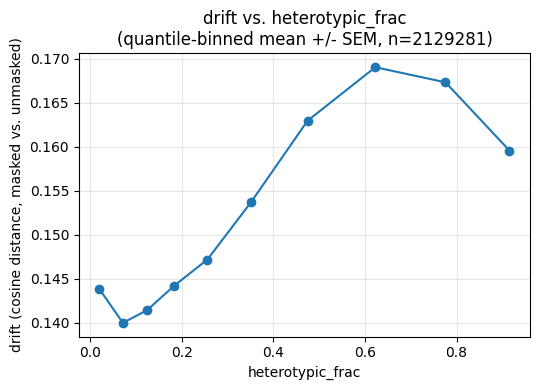

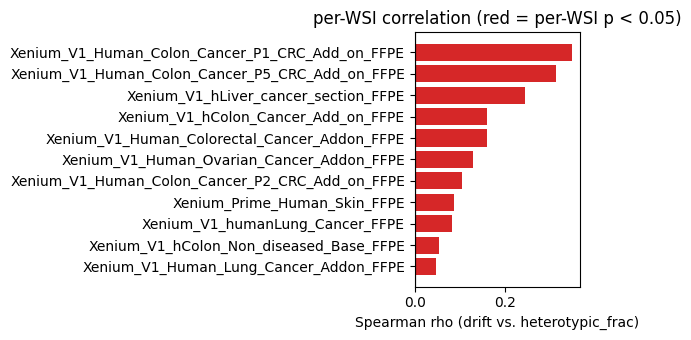

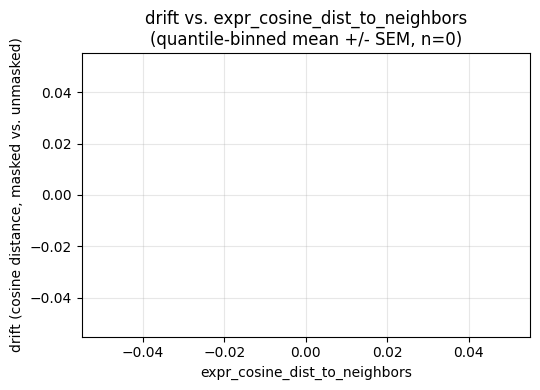

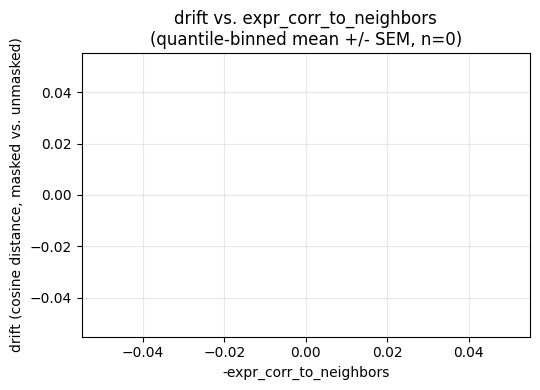

/tmp/ipykernel_3412190/993474356.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f"surrounded (n={len(data[0])})", f"isolated (n={len(data[1])})"], showfliers=False)


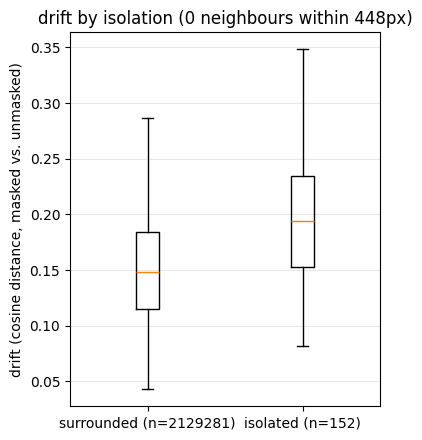

In [44]:
def plot_drift_vs_bio_score(df: pd.DataFrame, score_col: str, flip_sign: bool, n_bins: int = 10) -> None:
    """Quantile-binned mean +/- SEM of drift against score_col -- more legible than
    a raw per-cell scatter at this sample size, and matches the rank-based test
    above (a monotonic trend, not a specific parametric shape)."""
    x = -df[score_col] if flip_sign else df[score_col]
    valid = x.notna() & df["drift"].notna()
    x, y = x[valid], df.loc[valid, "drift"]
    bins = pd.qcut(x, q=n_bins, duplicates="drop")
    means, sems = y.groupby(bins, observed=True).mean(), y.groupby(bins, observed=True).sem()
    centers = x.groupby(bins, observed=True).mean()

    fig, ax = plt.subplots(figsize=(5.5, 4))
    ax.errorbar(centers, means, yerr=sems, marker="o", capsize=3)
    ax.set_xlabel(("-" if flip_sign else "") + score_col)
    ax.set_ylabel("drift (cosine distance, masked vs. unmasked)")
    ax.set_title(f"drift vs. {score_col}\n(quantile-binned mean +/- SEM, n={len(x)})")
    ax.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()


def plot_per_wsi_correlations(per_wsi: pd.DataFrame, score_col: str) -> None:
    fig, ax = plt.subplots(figsize=(6, 3.5))
    order = per_wsi.sort_values("rho")
    colors = ["tab:red" if p < 0.05 else "tab:gray" for p in order["p_value"]]
    ax.barh(order["wsi_name"], order["rho"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel(f"Spearman rho (drift vs. {score_col})")
    ax.set_title("per-WSI correlation (red = per-WSI p < 0.05)")
    fig.tight_layout()
    plt.show()


def plot_isolation_boxplot(df: pd.DataFrame) -> None:
    sub = df[df["drift"].notna() & df["position_found"]]
    fig, ax = plt.subplots(figsize=(4, 4.5))
    data = [sub.loc[~sub["isolated"], "drift"], sub.loc[sub["isolated"], "drift"]]
    ax.boxplot(data, labels=[f"surrounded (n={len(data[0])})", f"isolated (n={len(data[1])})"], showfliers=False)
    ax.set_ylabel("drift (cosine distance, masked vs. unmasked)")
    ax.set_title(f"drift by isolation (0 neighbours within {CONTEXT_PX}px)")
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()
    plt.show()


for score_col, (flip, _description) in BIO_SCORES.items():
    plot_drift_vs_bio_score(analysis_df, score_col, flip_sign=flip)
    if len(per_wsi_by_score[score_col]):
        plot_per_wsi_correlations(per_wsi_by_score[score_col], score_col)

plot_isolation_boxplot(analysis_df)